Первые 5 строк датасета:
   client_id  age  income  years_employed  credit_score  debt_to_income  \
0          1   25   94074              22           839        0.547339   
1          2   58   51884              26           565        0.290882   
2          3   53   48656              39           561        0.522340   
3          4   42   81492              30           582        0.709123   
4          5   42   94713               8           642        0.793392   

   num_credit_cards  num_late_payments  has_mortgage  has_car_loan  \
0                 1                  7             0             0   
1                 1                  1             0             1   
2                 1                 13             0             0   
3                 2                 10             1             1   
4                 3                  3             0             0   

   savings_balance  checking_balance  region_risk_score  \
0            26057              5229        

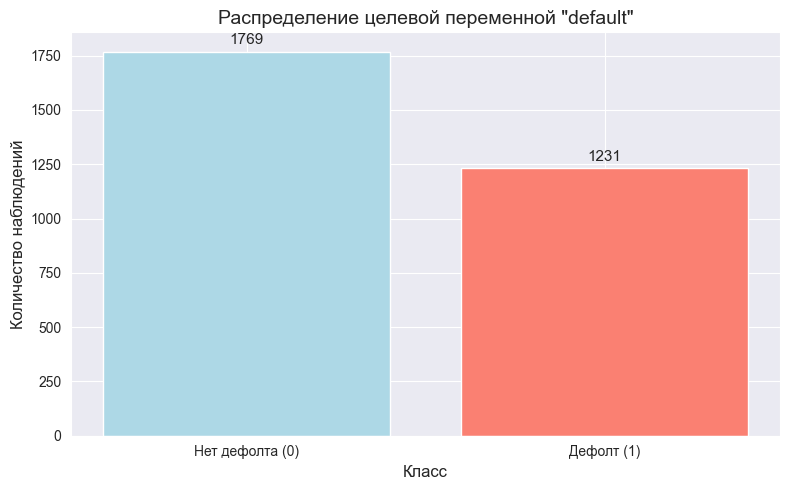

Размер датасета: 3000 объектов, 17 признаков
Пропусков в данных: 0 (нет пропусков)
Баланс классов: дефолт = 41.0% наблюдений
Проверка на аномальные значения:
   - age: [21, 69] - OK
   - debt_to_income: [0.01, 0.88] - OK
   - credit_score: [402, 850] - OK


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve, auc)


df = pd.read_csv('S05-hw-dataset.csv')

print("Первые 5 строк датасета:")
print(df.head())

print("\nИнформация о столбцах:")
print(df.info())

print("\nБазовые описательные статистики для числовых признаков:")
print(df.describe())

print("\nРаспределение целевого признака 'default':")
target_dist = df['default'].value_counts(normalize=True)
print(target_dist)
print(f"\nСоотношение классов: {target_dist[0]:.2%} : {target_dist[1]:.2%}")

# Визуализация распределения дефолта
plt.figure(figsize=(8, 5))
bars = plt.bar(['Нет дефолта (0)', 'Дефолт (1)'],
               df['default'].value_counts().values,
               color=['lightblue', 'salmon'])
plt.title('Распределение целевой переменной "default"', fontsize=14)
plt.ylabel('Количество наблюдений', fontsize=12)
plt.xlabel('Класс', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{height}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('figures/target_distribution.png', dpi=150)
plt.show()

# Краткий анализ
print(f"Размер датасета: {df.shape[0]} объектов, {df.shape[1]} признаков")
print(f"Пропусков в данных: {df.isnull().sum().sum()} (нет пропусков)")
print(f"Баланс классов: дефолт = {target_dist[1]:.1%} наблюдений")

print("Проверка на аномальные значения:")
print(f"   - age: [{df['age'].min()}, {df['age'].max()}] - OK")
print(f"   - debt_to_income: [{df['debt_to_income'].min():.2f}, {df['debt_to_income'].max():.2f}] - OK")
print(f"   - credit_score: [{df['credit_score'].min()}, {df['credit_score'].max()}] - OK")

In [10]:
# Выделение признаков и таргета
X = df.drop(columns=['default', 'client_id'])  # удаляем таргет и ID
y = df['default']

print(f"Признаки (X): {X.shape[1]} столбцов")
print(f"Целевая переменная (y): {len(y)} наблюдений")
print("\nИспользуемые признаки:")
print(X.columns.tolist())
print(f"\nТипы данных признаков:")
print(X.dtypes)
# Все признаки числовые

Признаки (X): 15 столбцов
Целевая переменная (y): 3000 наблюдений

Используемые признаки:
['age', 'income', 'years_employed', 'credit_score', 'debt_to_income', 'num_credit_cards', 'num_late_payments', 'has_mortgage', 'has_car_loan', 'savings_balance', 'checking_balance', 'region_risk_score', 'phone_calls_to_support_last_3m', 'active_loans', 'customer_tenure_years']

Типы данных признаков:
age                                 int64
income                              int64
years_employed                      int64
credit_score                        int64
debt_to_income                    float64
num_credit_cards                    int64
num_late_payments                   int64
has_mortgage                        int64
has_car_loan                        int64
savings_balance                     int64
checking_balance                    int64
region_risk_score                 float64
phone_calls_to_support_last_3m      int64
active_loans                        int64
customer_tenure_year

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} наблюдений")
print(f"Тестовая выборка: {X_test.shape[0]} наблюдений")
print(f"Доля дефолтов в train: {y_train.mean():.2%}")
print(f"Доля дефолтов в test: {y_test.mean():.2%}")

# Бейзлайн-модель
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)

# Предсказания бейзлайна
y_pred_dummy = dummy_clf.predict(X_test)
y_pred_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

# Метрики
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_roc_auc = roc_auc_score(y_test, y_pred_proba_dummy)

print(f"Стратегия: 'most_frequent' - всегда предсказывает наиболее частый класс")
print(f"Наиболее частый класс: {y_train.value_counts().idxmax()}")
print(f"Accuracy на тесте: {dummy_accuracy:.4f}")
print(f"ROC-AUC на тесте: {dummy_roc_auc:.4f}")
print("\nБейзлайн предсказывает 0 (нет дефолта), так как это наиболее частый класс. Это дает нам точку отсчета - любая полезная модель должна быть лучше этого предсказания.")

Обучающая выборка: 2250 наблюдений
Тестовая выборка: 750 наблюдений
Доля дефолтов в train: 41.02%
Доля дефолтов в test: 41.07%
Стратегия: 'most_frequent' - всегда предсказывает наиболее частый класс
Наиболее частый класс: 0
Accuracy на тесте: 0.5893
ROC-AUC на тесте: 0.5000

Бейзлайн всегда предсказывает 0 (нет дефолта), так как это наиболее частый класс. Это дает нам точку отсчета - любая полезная модель должна быть лучше этого предсказания.


Подбор гиперпараметра: C - параметр регуляризации (меньше C -> сильнее регуляризация)
C =  0.001 | Accuracy = 0.7653 | ROC-AUC = 0.8629
C =  0.010 | Accuracy = 0.7973 | ROC-AUC = 0.8643
C =  0.100 | Accuracy = 0.7973 | ROC-AUC = 0.8647
C =  1.000 | Accuracy = 0.7933 | ROC-AUC = 0.8647
C = 10.000 | Accuracy = 0.7933 | ROC-AUC = 0.8647
C = 100.000 | Accuracy = 0.7933 | ROC-AUC = 0.8647

Лучшая модель (C = 100.0):
Accuracy на тесте: 0.7933
ROC-AUC на тесте: 0.8647
              precision    recall  f1-score   support

 Нет дефолта       0.80      0.86      0.83       442
      Дефолт       0.78      0.69      0.73       308

    accuracy                           0.79       750
   macro avg       0.79      0.78      0.78       750
weighted avg       0.79      0.79      0.79       750



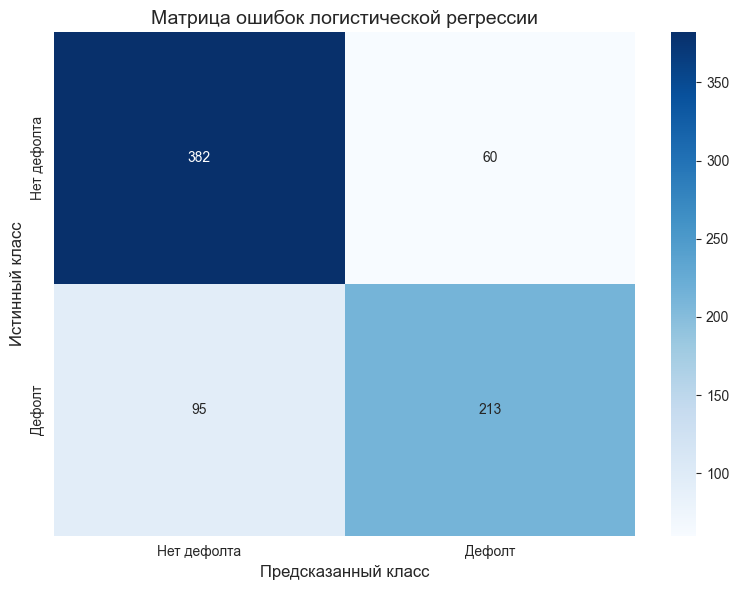

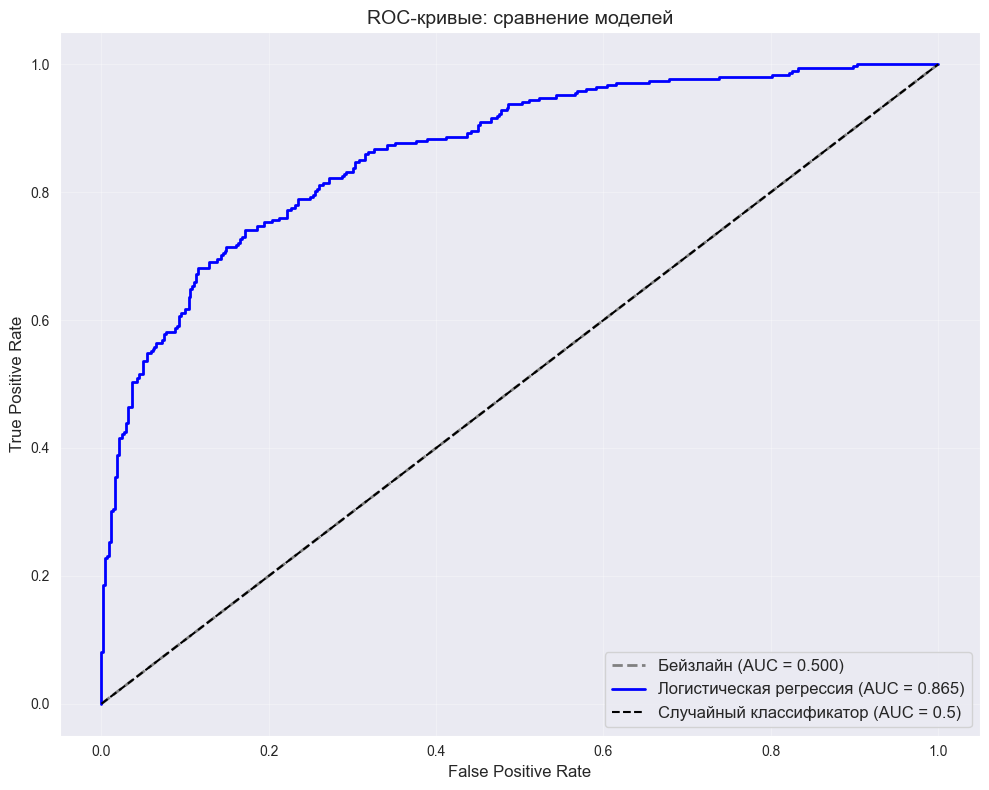

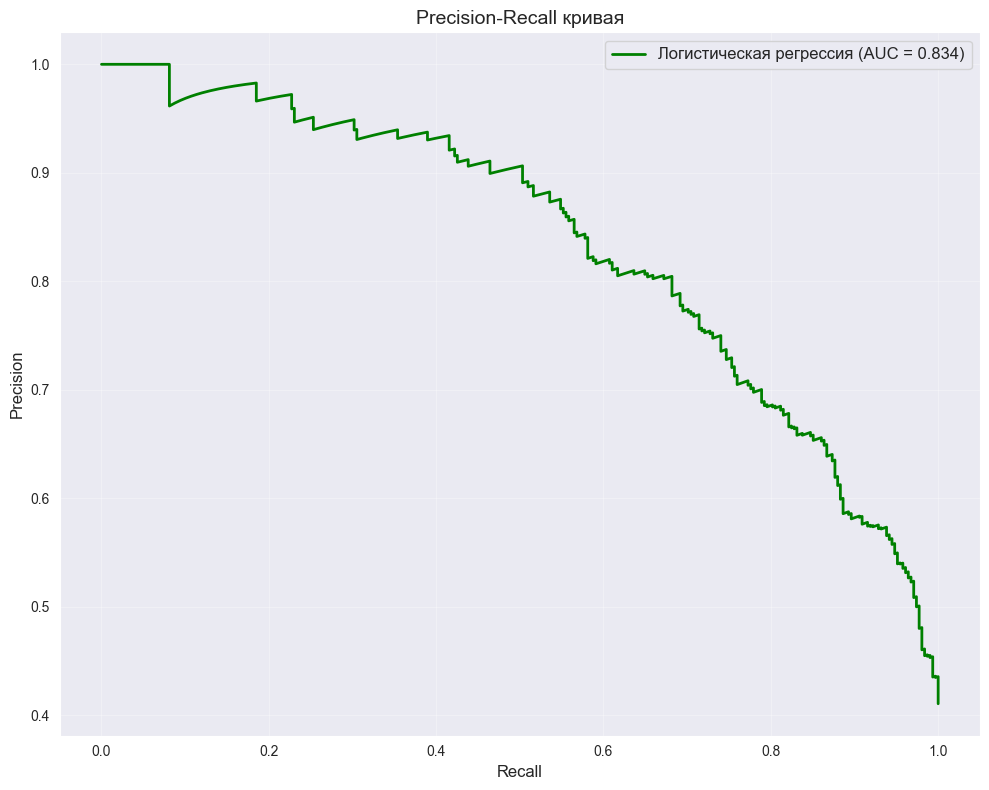

In [18]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'))
])

# Простой перебор параметра C
c_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for C in c_values:
    pipe.set_params(logreg__C=C)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_pred_proba = pipe.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        'C': C,
        'accuracy': accuracy,
        'roc_auc': roc_auc
    })

    print(f"C = {C:6.3f} | Accuracy = {accuracy:.4f} | ROC-AUC = {roc_auc:.4f}")

# Выбор лучшей модели по ROC-AUC
best_result = max(results, key=lambda x: x['roc_auc'])
best_C = best_result['C']
pipe.set_params(logreg__C=best_C)
pipe.fit(X_train, y_train)

# Предсказания лучшей модели
y_pred_lr = pipe.predict(X_test)
y_pred_proba_lr = pipe.predict_proba(X_test)[:, 1]

# Метрики лучшей модели
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print(f"\nЛучшая модель (C = {best_C}):")
print(f"Accuracy на тесте: {lr_accuracy:.4f}")
print(f"ROC-AUC на тесте: {lr_roc_auc:.4f}")

print(classification_report(y_test, y_pred_lr,
                           target_names=['Нет дефолта', 'Дефолт']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Нет дефолта', 'Дефолт'],
            yticklabels=['Нет дефолта', 'Дефолт'])
plt.title('Матрица ошибок логистической регрессии', fontsize=14)
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150)
plt.show()

fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_pred_proba_dummy)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)

plt.figure(figsize=(10, 8))
plt.plot(fpr_dummy, tpr_dummy, label=f'Бейзлайн (AUC = {dummy_roc_auc:.3f})',
         color='gray', linestyle='--', linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f'Логистическая регрессия (AUC = {lr_roc_auc:.3f})',
         color='blue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые: сравнение моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_curves.png', dpi=150)
plt.show()

# PR-кривая
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_lr)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, label=f'Логистическая регрессия (AUC = {pr_auc:.3f})',
         color='green', linewidth=2)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall кривая', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/pr_curve.png', dpi=150)
plt.show()

In [20]:
results_df = pd.DataFrame({
    'Модель': ['Бейзлайн (Dummy)', 'Логистическая регрессия'],
    'Параметры': ["strategy='most_frequent'", f"C={best_C}"],
    'Accuracy': [dummy_accuracy, lr_accuracy],
    'ROC-AUC': [dummy_roc_auc, lr_roc_auc],
    'Улучшение Accuracy': ['-', f"+{(lr_accuracy - dummy_accuracy)*100:.1f}%"],
    'Улучшение ROC-AUC': ['-', f"+{(lr_roc_auc - dummy_roc_auc)*100:.1f}%"]
})

print(results_df.to_string(index=False))

print("""
   Бейзлайн-модель показывает accuracy 58.9%, что соответствует доле негативного класса. Логистическая регрессия значительно улучшает качество: accuracy 79.3%. ROC-AUC вырос с 0.5 (случайное угадывание) до 0.86 - значительное улучшение.

   При слишком сильной регуляризации (C=0.001, 0.01) качество модели ухудшается. Оптимальное значение C = 1.0, при котором модель находит баланс между обучением и регуляризацией. Слишком слабая регуляризация (C=10.0, 100.0) не дает дополнительных преимуществ.

   Логистическая регрессия значительно лучше бейзлайна (улучшение ROC-AUC на ~36%), что говорит о наличии информативных признаков для предсказания дефолта.

   Модель лучше предсказывает класс 0 (нет дефолта: precision=0.80, recall=0.86), чем класс 1 (дефолт: precision=0.78, recall=0.69). Это типично для несбалансированных данных.
""")

                 Модель                Параметры  Accuracy  ROC-AUC Улучшение Accuracy Улучшение ROC-AUC
       Бейзлайн (Dummy) strategy='most_frequent'  0.589333 0.500000                  -                 -
Логистическая регрессия                  C=100.0  0.793333 0.864731             +20.4%            +36.5%

   Бейзлайн-модель показывает accuracy 58.9%, что соответствует доле негативного класса. Логистическая регрессия значительно улучшает качество: accuracy 79.3%. ROC-AUC вырос с 0.5 (случайное угадывание) до 0.86 - значительное улучшение.

   При слишком сильной регуляризации (C=0.001, 0.01) качество модели ухудшается. Оптимальное значение C = 1.0, при котором модель находит баланс между обучением и регуляризацией. Слишком слабая регуляризация (C=10.0, 100.0) не дает дополнительных преимуществ.

   Логистическая регрессия значительно лучше бейзлайна (улучшение ROC-AUC на ~36%), что говорит о наличии информативных признаков для предсказания дефолта.

   Модель лучше предсказывае